In [1]:
from model import *
import timm
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("Pre-Trained Directory/tokenizer.json")
import torchvision.transforms as T
import torchvision.io as io

device='mps'

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pad_id = tokenizer.encode('[PAD]').ids
unk_id = tokenizer.encode('[UNK]').ids
bos_id = tokenizer.encode('[BOS]').ids
eos_id = tokenizer.encode('[EOS]').ids
sep_id = tokenizer.encode('[SEP]').ids
img_token_id = tokenizer.encode('[IMG_TOKEN]').ids

In [3]:
def build_img_model():
    img_emb_model = timm.create_model('mobilevitv2_050.cvnets_in1k', pretrained=True,features_only=True)
    data_config = timm.data.resolve_model_data_config(img_emb_model)
    return img_emb_model, data_config

In [4]:
class VLM(torch.nn.Module):
    def __init__(self,*, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate) 
        self.d_model = d_model
        self.img_emb_model, self.data_config = build_img_model()
        self.dense = torch.nn.Sequential(
            torch.nn.LayerNorm(self.d_model, eps=1e-5),
            torch.nn.Linear(self.d_model, self.d_model),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.d_model, self.d_model),
            torch.nn.Dropout(0.1)
        )

        # Freeze pretrained components
        for param in self.token_embedding.parameters():
            param.requires_grad = False
        for param in self.decoder.parameters():
            param.requires_grad = False
        for param in self.img_emb_model.parameters():
            param.requires_grad = False

        self.img_seq_len = 64

        self.transform = T.Compose([
            T.Resize(self.data_config['input_size'][1:]),           # expects (C,H,W) in torch, so this works with torchvision v0.13+
            T.CenterCrop(self.data_config['input_size'][1:]),
            T.Normalize(mean=self.data_config['mean'], std=self.data_config['std'])
        ])

    def load_pretrained_weights(self, token_emb_path, decoder_path):
        # Load token embedding weights
        token_ckpt = torch.load(token_emb_path, map_location=device)
        if "token_embedding" in token_ckpt:
            token_ckpt = token_ckpt["token_embedding"]
        self.token_embedding.load_state_dict(token_ckpt)

        # Load decoder weights
        decoder_ckpt = torch.load(decoder_path, map_location=device)
        if "decoder" in decoder_ckpt:
            decoder_ckpt = decoder_ckpt["decoder"]
        self.decoder.load_state_dict(decoder_ckpt)

    def forward(self, inputs):
        image_paths,tokens = inputs
        pad_mask = tokens == 0

        # Process images (batch)
        imgs = []
        for p in image_paths:
            img = io.read_image(p)  # (C, H, W)
            if img.shape[0] == 1:   # If grayscale → repeat channels
                img = img.repeat(3, 1, 1)
            img = img.float() / 255.0
            imgs.append(img)
        img_tensors = torch.stack([self.transform(img) for img in imgs]).to(tokens.device)

        feature = self.img_emb_model(img_tensors)[-1]  # (B, C, H, W)
        B, C, H, W = feature.shape
        img_emb = feature.permute(0, 2, 3, 1).reshape(B, H * W, C) # (B,H*W,256) our d_model is 256 by default
        img_emb = self.dense(img_emb)

        text_emb = self.token_embedding(tokens)

        start_id_ = text_emb[:,:1,:] # bos_id 
        x = torch.cat([start_id_,img_emb,text_emb[:,1 + self.img_seq_len:,:]],dim=1)
        logits = self.decoder(x,pad_mask=pad_mask)
        return logits

In [5]:
import json
import pandas as pd
import numpy as np

# Open and read the JSON file  https://huggingface.co/datasets/liuhaotian/LLaVA-Pretrain
with open("/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/blip_laion_cc_sbu_558k.json", "r") as file:
    data = json.load(file)  # Parse the JSON data into a Python dictionary

# Convert to DataFrame
df1 = pd.DataFrame([{
    'id': item['id'],
    'img_path': '/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/'+item['image'],
    'input_text': next(conv['value'] for conv in item['conversations'] if conv['from'] == 'human'),
    'target_text': next(conv['value'] for conv in item['conversations'] if conv['from'] == 'gpt')
} for item in data]).dropna().reset_index(drop=True)

df1['input_text'] = None

question_pool = [
    'Render a clear and concise summary of the photo.\n<image>',
    'Write a terse but informative summary of the picture.\n<image>',
    '<image>\nWhat is this?',
    '<image>\nRender a clear and concise summary of the photo.',
    'What is in the photo?\n<image>',
    'Describe the image concisely.\n<image>',
    'Share a concise interpretation of the image provided.\n<image>',
    'Give a brief description of the image.\n<image>',
    "<image>\nPresent a compact description of the photo's key features.",
    '<image>\nDescribe the image concisely.', 'What is this?\n<image>',
    '<image>\nWrite a terse but informative summary of the picture.',
    'Provide a brief description of the given image.\n<image>',
    'Summarize the visual content of the image.\n<image>',
    '<image>\nWhat is in the photo?',
    '<image>\nProvide a brief description of the given image.',
    "Present a compact description of the photo's key features.\n<image>",
    'Give a short and clear explanation of the subsequent image.\n<image>',
    '<image>\nGive a short and clear explanation of the subsequent image.',
    '<image>\nGive a brief description of the image.',
    '<image>\nSummarize the visual content of the image.',
    '<image>\nShare a concise interpretation of the image provided.'
    "What is present in the image?",
    "How would you describe the background setting?",
    "What is the central subject or point of focus?",
    "What is happening in the image?",
    "Where might this photo have been taken?",
    "Describe the image.",
    "Are there people in the picture?",
    "Is there an animal in the picture?",
    "What objects are visible in the image?",
    "What activity or event is occurring in the image?",
    "Can you describe the colors present in the image?",
    "What do you think the mood or atmosphere of the image is?",
    "What draws your attention most in the image?",
    "Does the image appear to be candid or posed?",
    "Is there any text or signage visible in the image?",
    "Are there any buildings or structures visible?",
    "Does the image convey any emotions or feelings?",
    "Are there any artistic or stylistic elements in the photo?",
    "If you could give this image a title, what would it be?",
    'What is unique about the image?',
]

# Assign questions per img_path group
for img_path, group in df1.groupby('img_path'):
    indices = group.index.tolist()
    available_questions = question_pool.copy()
    np.random.shuffle(available_questions)
    
    # If more rows than questions, cycle through questions
    while len(available_questions) < len(indices):
        extra = question_pool.copy()
        np.random.shuffle(extra)
        available_questions += extra

    for i, idx in enumerate(indices):
        df1.at[idx, 'input_text'] = available_questions[i]
df1 = df1[['img_path','target_text','input_text']]
df1

,img_path,target_text,input_text
0,/Users/saptarshimallikthakur/Pictures/VLM data...,select luxury furniture 3 - inch gel memory fo...,Summarize the visual content of the image.\n<i...
1,/Users/saptarshimallikthakur/Pictures/VLM data...,a grey watch with an army style strap,Does the image appear to be candid or posed?
2,/Users/saptarshimallikthakur/Pictures/VLM data...,a dragon kite flying in the blue sky stock images,What is unique about the image?
3,/Users/saptarshimallikthakur/Pictures/VLM data...,$ 10 - cute cheap printed mini dress - khaki m...,Render a clear and concise summary of the phot...
4,/Users/saptarshimallikthakur/Pictures/VLM data...,augmented reality using aruco markers in opencv,Write a terse but informative summary of the p...
...,...,...,...
558123,/Users/saptarshimallikthakur/Pictures/VLM data...,paper quilled letters of the alphabet h with c...,<image>\nGive a short and clear explanation of...
558124,/Users/saptarshimallikthakur/Pictures/VLM data...,"a jabra corded headset with usb sync, power co...",Does the image convey any emotions or feelings?
558125,/Users/saptarshimallikthakur/Pictures/VLM data...,"an apple ii computer, with a computer monitor ...",What is unique about the image?
558126,/Users/saptarshimallikthakur/Pictures/VLM data...,us03498792 figure 1 from a patent drawing of a...,What is happening in the image?


In [6]:
with open('/Users/saptarshimallikthakur/Pictures/VLM dataset/fsvqa/fsvqa_original/fsvqa_original_train_questions.json', 'r') as f:
    data = json.load(f)

# 'questions' is expected to be a list of dictionaries
questions = data['questions']

# Convert list of dicts to DataFrame
df2 = pd.DataFrame(questions)[['img_id', 'question', 'question_id']]
df2.reset_index(drop=True, inplace=True)

# Step 1: Load the raw JSON structure
with open('/Users/saptarshimallikthakur/Pictures/VLM dataset/fsvqa/fsvqa_original/fsvqa_original_train_annotations.json', 'r') as f:
    data = json.load(f)

# Step 2: Extract the list of annotation dicts
annotations = data['annotations']  # each item contains 'question_id' and 'answers'

# Step 3: Flatten the data
# Each annotation contains a list of 'answers', so we need to explode that
flat_data = []
for ann in annotations:
    question_id = ann['question_id']
    img_id = ann['img_id']
    for ans in ann['answers']:
        flat_data.append({
            'question_id': question_id,
            'img_id': img_id,
            'answer': ans['answer']
        })

# Step 4: Convert to DataFrame
df3 = pd.DataFrame(flat_data)

# Optional: Reset index and show a few rows
df3.reset_index(drop=True, inplace=True)

df4 = pd.merge(df2,df3,how='left',on='question_id').drop(columns=['img_id_y']).rename(columns={'img_id_x': 'img_id'})
df4 = df4.sort_values(by='img_id').reset_index(drop=True)[['img_id','question','answer']]
df4['img_id'] = df4['img_id'].apply(lambda x: '/Users/saptarshimallikthakur/Pictures/VLM dataset/fsvqa/train2014/'+str(x)+'.jpg')
df4 = df4.rename(columns={'img_id':'img_path','question':'input_text','answer':'target_text'})
df4

,img_path,input_text,target_text
0,/Users/saptarshimallikthakur/Pictures/VLM data...,What is the green stuff?,The green stuff is broccoli.
1,/Users/saptarshimallikthakur/Pictures/VLM data...,How many cookies can be seen?,2 cookies can be seen.
2,/Users/saptarshimallikthakur/Pictures/VLM data...,What color are the dishes?,The dishes are pink and yellow.
3,/Users/saptarshimallikthakur/Pictures/VLM data...,Are both giraffes standing?,"No, both giraffes are not standing."
4,/Users/saptarshimallikthakur/Pictures/VLM data...,Where is the giraffe?,The giraffe is at near tree.
...,...,...,...
248344,/Users/saptarshimallikthakur/Pictures/VLM data...,Is this boat in the water?,"No, this boat is not in the water."
248345,/Users/saptarshimallikthakur/Pictures/VLM data...,Are there storm clouds?,"Yes, there are storm clouds."
248346,/Users/saptarshimallikthakur/Pictures/VLM data...,Is the snow deep?,"Yes, the snow is deep."
248347,/Users/saptarshimallikthakur/Pictures/VLM data...,Is there a lot of snow on the floor?,"Yes, there is a lot of snow on the floor."


In [7]:
df = pd.concat([df1,df4])[['input_text','target_text','img_path']].reset_index(drop=True)
del(df1)
del(df2)
del(df3)
del(df4)
df

,input_text,target_text,img_path
0,Summarize the visual content of the image.\n<i...,select luxury furniture 3 - inch gel memory fo...,/Users/saptarshimallikthakur/Pictures/VLM data...
1,Does the image appear to be candid or posed?,a grey watch with an army style strap,/Users/saptarshimallikthakur/Pictures/VLM data...
2,What is unique about the image?,a dragon kite flying in the blue sky stock images,/Users/saptarshimallikthakur/Pictures/VLM data...
3,Render a clear and concise summary of the phot...,$ 10 - cute cheap printed mini dress - khaki m...,/Users/saptarshimallikthakur/Pictures/VLM data...
4,Write a terse but informative summary of the p...,augmented reality using aruco markers in opencv,/Users/saptarshimallikthakur/Pictures/VLM data...
...,...,...,...
806472,Is this boat in the water?,"No, this boat is not in the water.",/Users/saptarshimallikthakur/Pictures/VLM data...
806473,Are there storm clouds?,"Yes, there are storm clouds.",/Users/saptarshimallikthakur/Pictures/VLM data...
806474,Is the snow deep?,"Yes, the snow is deep.",/Users/saptarshimallikthakur/Pictures/VLM data...
806475,Is there a lot of snow on the floor?,"Yes, there is a lot of snow on the floor.",/Users/saptarshimallikthakur/Pictures/VLM data...


In [8]:
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    # text = text.lower()
    text = re.sub(r'<image>', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z0-9.,!?]+', ' ', text)
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df['target_text'] = df['target_text'].apply(lambda x: clean_text(x))
df['input_text'] = df['input_text'].apply(lambda x: clean_text(x))

100%|██████████| 806477/806477 [00:20<00:00, 39159.30it/s]


Total samples    : 806,477
Min / Max tokens : 4 / 84
Mean ± std       : 20.7 ± 6.8
--- percentiles (tokens) ---
 50% : 20
 90% : 30
 95% : 33
 98% : 37
 99% : 39


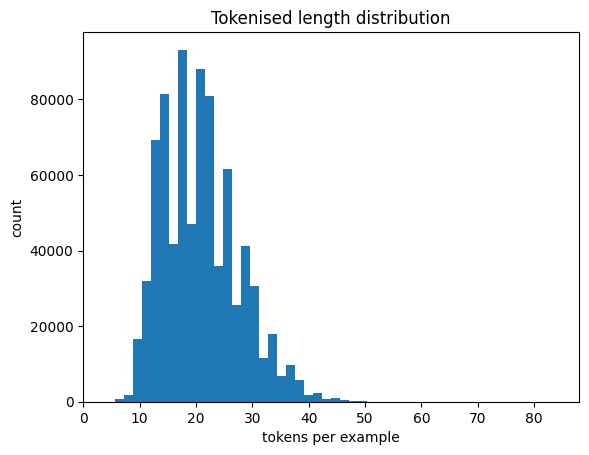

In [9]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 0)  Make sure `tok` points to the FINAL tokenizer
#     → trained on the full corpus with your chosen vocab_size
# ------------------------------------------------------------
tok = tokenizer          # whatever variable you use

# ------------------------------------------------------------
# 1)  Get token counts for every example
#     (here: concatenate summary + dialogue; split if you want)
# ------------------------------------------------------------
lens = []

for s, d in tqdm(zip(df["input_text"], df["target_text"]),
                 total=len(df)):
    iids   = tok.encode(s).ids
    tids   = tok.encode(d).ids
    
    lens.append(len(iids+tids))

lens = np.array(lens)

# ------------------------------------------------------------
# 2)  Print key stats
# ------------------------------------------------------------
def pct(x): return np.percentile(lens, x)

print(f"Total samples    : {len(lens):,}")
print(f"Min / Max tokens : {lens.min()} / {lens.max()}")
print(f"Mean ± std       : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- percentiles (tokens) ---")
for p in (50, 90, 95, 98, 99):
    print(f"{p:>3}% : {pct(p):.0f}")

# ------------------------------------------------------------
# 3)  Quick histogram    (no seaborn, single plot, no colors set)
# ------------------------------------------------------------
plt.hist(lens, bins=50)
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.title("Tokenised length distribution")
plt.show()

In [10]:
# Configuration
VOCAB_SIZE = 12000
MAX_LEN = 64 + int(pct(99)) + 1 + 2 # BOS,SEP & SEP,EOS
MAX_INPUT_LEN = 512
BATCH_SIZE = 32
num_layers = 3
d_model = 256
num_heads = 8
dropout_rate = 0.1
IMG_SHAPE = (256, 256, 3)

# Build and load VLM
vlm = VLM(
    input_vocab_size=VOCAB_SIZE,
    d_model=d_model,
    num_layers=num_layers,
    num_heads=num_heads,
)

vlm.to(device)

# Load pre-trained weights
vlm.load_pretrained_weights(
    token_emb_path="Pre-Trained Directory/pretrained_embedding_dict.pth",
    decoder_path="Pre-Trained Directory/pretrained_decoder_dict.pth"
)

dummy_path = ["/Users/saptarshimallikthakur/Pictures/New Folder With Items/cat.jpeg"]
dummy_tokens = torch.zeros((1, MAX_INPUT_LEN), dtype=torch.long).to(device)
_ = vlm((dummy_path,dummy_tokens))

In [11]:
print("Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in vlm.named_parameters():
    if param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Trainable Parameters: {total_params:,}")

Trainable Parameters:
------------------------------------------------------------
Parameter: dense.0.weight                                     Shape: torch.Size([256])    Parameters: 256
Parameter: dense.0.bias                                       Shape: torch.Size([256])    Parameters: 256
Parameter: dense.1.weight                                     Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: dense.1.bias                                       Shape: torch.Size([256])    Parameters: 256
Parameter: dense.4.weight                                     Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: dense.4.bias                                       Shape: torch.Size([256])    Parameters: 256
------------------------------------------------------------
Total Trainable Parameters: 132,096


In [12]:
print("Non Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in vlm.named_parameters():
    if not param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Non Trainable Parameters: {total_params:,}")

Non Trainable Parameters:
------------------------------------------------------------
Parameter: token_embedding.embedding.weight                   Shape: torch.Size([12000, 256]) Parameters: 3072000
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wq.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wk.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wv.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wo.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.rmsnorm.scale Shape: torch.Size([256])    Parameters: 256
Parameter: decoder.dec_layers.0.ffn.swiglu.lin1.weight        Shape: torch.Size([1024, 256]) Parameters: 262144
Parameter: decoder.dec_layers.0.ffn.swiglu.lin2.weight        Shape: torch.Size([256, 512]) Parameters: 131072


In [13]:
# 1) encode_pair → return a NumPy array
def encode_pair(text_a: str, text_b: str) -> np.ndarray:
    enc = bos_id + img_token_id*64 + tokenizer.encode(text_a).ids + sep_id + tokenizer.encode(text_b).ids 
    enc = enc[:MAX_LEN]
    return enc

def encode_example(img_path, text: str, summary: str):
    ids = encode_pair(text, summary)     
    labels = ids[1:]

    ids = ids + pad_id*(MAX_LEN-len(ids))
    
    labels = labels + eos_id 
    labels = labels + pad_id*(MAX_LEN-len(labels))

    ids = np.array(ids,dtype=np.int32)
    labels = np.array(labels,dtype=np.int32)

    # find SEP
    SEP_idxs = np.where(labels == sep_id)[0]
    SEP_pos = int(SEP_idxs[0]) if SEP_idxs.size else len(ids)

    # build base mask: 1 only for positions > sep_pos AND not PAD
    positions = np.arange(len(labels))
    loss_mask = (positions > SEP_pos).astype(np.float32) * (labels != pad_id).astype(np.float32)

    # Remove SEP from ids, labels, and loss_mask
    sep_mask_ids = (ids != sep_id[0])
    sep_mask_labels = (labels != sep_id[0])
    
    ids = ids[sep_mask_ids]
    labels = labels[sep_mask_labels]
    loss_mask = loss_mask[sep_mask_labels]

    return img_path, ids, labels.astype(np.int32), loss_mask

In [14]:
text_pairs = []

for img,i,j in zip(df.img_path,df.input_text,df.target_text):
    text_pairs.append((img,i,j))

len(text_pairs), text_pairs[:5]

(806477,
 [('/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/00453/004539375.jpg',
   'summarize the visual content of the image.',
   'select luxury furniture 3 inch gel memory foam mattress topper'),
  ('/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/00223/002239345.jpg',
   'does the image appear to be candid or posed?',
   'a grey watch with an army style strap'),
  ('/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/00594/005947502.jpg',
   'what is unique about the image?',
   'a dragon kite flying in the blue sky stock images'),
  ('/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/00511/005116462.jpg',
   'render a clear and concise summary of the photo.',
   '10 cute cheap printed mini dress khaki multicolor striped floral print peasant short sleeve tunic'),
  ('/Users/saptarshimallikthakur/Pictures/VLM dataset/blip images/images/00201/002017886.jpg',
   'write a terse but informative summary of t

In [15]:
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, img_path, ids, labels, masks):
        self.img_path = img_path
        self.ids = ids
        self.labels = labels
        self.masks = masks

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return {
            "img_path": self.img_path[idx],   # string
            "input_ids": self.ids[idx],
            "labels": self.labels[idx],
            "loss_mask": self.masks[idx]
        }
    
triples = [encode_example(img, t, s) for (img, t, s) in text_pairs]

# Unpack
img_path, ids, labels, masks = zip(*triples)

# Keep img_path as a list (strings cannot be tensors)
img_path = list(img_path)

# Convert others to tensors
ids = torch.tensor(np.stack(ids, 0), dtype=torch.long)
labels = torch.tensor(np.stack(labels, 0), dtype=torch.long)
masks = torch.tensor(np.stack(masks, 0), dtype=torch.long)


dataset = MyDataset(img_path, ids, labels, masks)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

del(triples)
del(img_path)
del(ids)
del(labels)
del(masks)
del(df)
del(dataset)
del(text_pairs)

In [16]:
vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tok = id_to_token.get(tid, '?')
        if tok == '$':
            continue  # Skip the '$' symbol
        if tok.startswith('Ġ'):
            tok = tok[1:]  # Remove the space prefix indicator
            tokens.append(' ' + tok)
        else:
            tokens.append(tok)
    return ' '.join(tokens).strip()

for batch_idx, batch in enumerate(dataloader):
    if batch_idx >= 10:  # Equivalent to .take(10)
        break
    
    # Extract batch data
    img_paths = batch['img_path']           # list of strings
    input_ids = batch['input_ids'].numpy()  # shape (batch, MAX_LEN)
    labels    = batch['labels'].numpy()     # shape (batch, MAX_LEN)

    for i, (pth, ids_row, lbl_row) in enumerate(zip(img_paths, input_ids, labels), start=1):
        print(f"\n🟢 Sample {i}")
        print("  pth: ", pth)
        print("  Input IDs: ", ids_row.tolist())
        print("  Input:   ", decode_token_ids(ids_row.tolist()))
        print(" Target:   ", decode_token_ids(lbl_row.tolist()))
        print("  Label IDs: ", lbl_row.tolist())


🟢 Sample 1
  pth:  /Users/saptarshimallikthakur/Pictures/VLM dataset/fsvqa/train2014/84902.jpg
  Input IDs:  [2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 129, 348, 5232, 70, 4833, 36, 2075, 17, 348, 5232, 129, 70, 4833, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Input:    [BOS] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] 

In [17]:
print(batch["input_ids"][1])
print(batch["labels"][1])
print(batch["loss_mask"][1])

tensor([    2,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,   713,    70,  1983,   121,  1395,
         8095,   139,   114,  2019,  6022,   171,  5295,    19,  1132,  1417,
          206,   398,  6603,  1397,  1397,  2988, 11826,  1020,  9137,    17,
           24,  2319,    17,    24,    25,   688,     0,     0,     0,     0,
            0,     0,     0,     0,     0])
tensor([    5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5,     5,     5,     5,     5,     5,     5,     5,     5,
            5,     5

In [18]:
print(decode_token_ids(batch["input_ids"][1].tolist()))
print(decode_token_ids(batch["labels"][1].tolist()))
print(batch["labels"][1].tolist())
print(batch["loss_mask"][1].tolist())

[BOS] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] [IMG_TOKEN] give a short and clear explanation of the sub sequ ent image . clever nat ur als advance gold gold milk infant form ula , 3 months , 3 4 years [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
[IMG_TOKEN] [IMG_TOKEN] [IMG_

# Stage 1 Training

In [19]:
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm
import torch

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-1.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]
    

EPOCHS = 1
LEARNING_RATE_MIN = 1e-4
LEARNING_RATE_MAX = 1e-3
WARMUP_RATIO = 0

# --- Optimizer ---
optimizer = torch.optim.Adam(vlm.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9)
criterion = torch.nn.CrossEntropyLoss(reduction='none')  

# --- Calculate total steps and initialize scheduler ---
total_steps = len(dataloader) * EPOCHS
scheduler = CustomLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

for epoch in range(1, EPOCHS + 1):
    vlm.train()
    tot_loss = tot_correct = tot_tokens = 0.0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        paths = batch['img_path']
        ids = batch["input_ids"].to(device)          # (B, T)
        tgt = batch["labels"].to(device)             # (B, T)
        mask = batch["loss_mask"].to(device)         # (B, T)

        optimizer.zero_grad()
        logits = vlm((paths,ids))                          # (B, T, V)

        # ---- loss ----
        loss = criterion(logits.view(-1, logits.size(-1)), tgt.view(-1))  # (B*T,)
        masked_loss = (loss * mask.view(-1)).sum() / mask.sum().clamp(min=1)  # Apply mask and average
        masked_loss.backward()
        torch.nn.utils.clip_grad_norm_(vlm.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # ---- metrics (no grad) ----
        with torch.no_grad():
            preds = logits.argmax(-1)                # (B, T)
            valid = (mask == 1.0)                    # bool mask where loss_mask is 1.0
            correct = (preds == tgt) & valid         # Correct predictions where mask is 1.0
            n_tok = valid.sum().item()               # Count of masked tokens

            tot_correct += correct.sum().item()
            tot_tokens += n_tok
            tot_loss += masked_loss.item() * n_tok   # Scale by number of valid tokens

        pbar.set_postfix(
            loss=f"{tot_loss / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            acc=f"{tot_correct / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

Epoch 1/1: 100%|██████████| 25203/25203 [1:46:41<00:00,  3.94it/s, acc=0.1905, loss=5.6488, lr=0.000431]


In [20]:
torch.save(
    {"dense_projection": vlm.dense.state_dict()},
    "vlm directory/dense_projection_dict.pth"
)

In [21]:
import cv2

def encode(text: str) -> list[int]:
    full_ids = bos_id + img_token_id*64 + tokenizer.encode(text).ids 
    return full_ids

def generate_answer(vlm_model, image_path: str,
                    question:   str,
                    max_new_tokens: int = 30) -> str:
    
    # 1. Encode the prompt (image placeholders + question)
    # This creates: [BOS] [IMG]...[IMG] [Ques_START] [question] [SEP]
    prompt_ids = encode(clean_text(question))
    text_tokens = torch.tensor([prompt_ids], dtype=torch.int32).to(device)
    

    # 2. Autoregressive loop
    for _ in range(max_new_tokens):
        # Use direct model call for performance (not model.predict)
        # Pass training=False
        with torch.no_grad():
            logits = vlm_model(([image_path], text_tokens))[:, -1, :] / 0.1
        
        # Sample the next token
        next_id = torch.distributions.Categorical(logits=logits).sample().unsqueeze(0)

        # Append the new token
        text_tokens = torch.cat([text_tokens, next_id], dim=1)

        # Stop ONLY if EOS is generated
        if next_id[0, 0] == eos_id:
            break

    # 3. Decode the generated output
    generated_ids = text_tokens.cpu().numpy().tolist()[0] 

    print(generated_ids)
    
    # --- END FIX ---

    # Display image for context
    imgbgr = cv2.imread(image_path)
    if imgbgr is not None:
        imgrgb = cv2.cvtColor(imgbgr,cv2.COLOR_BGR2RGB)
        plt.imshow(imgrgb)
        plt.title(f"Q: {question}")
        plt.axis('off')
        plt.show()

    print(tokenizer.decode(generated_ids).strip())

[2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 340, 224, 150, 343, 36, 114, 291, 129, 70, 291, 320, 129, 70, 291, 179, 70, 512, 19, 3, 3, 291, 3, 19, 3, 291, 3, 88, 3, 88, 19, 3, 291, 3, 88, 3]


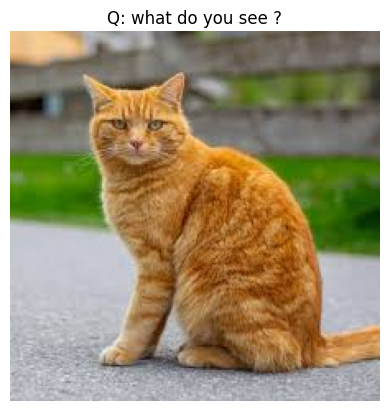

what do you see ? the man is a man who is a man with a hat . man . man s s . man s
None


In [22]:
img   =  "/Users/saptarshimallikthakur/Pictures/New Folder With Items/cat.jpeg"
ques  = "what do you see ?"
print(generate_answer(vlm, img, ques))

# Stage 2 Training

In [24]:
def build_img_model():
    img_emb_model = timm.create_model('mobilevitv2_050.cvnets_in1k', pretrained=True,features_only=True)
    data_config = timm.data.resolve_model_data_config(img_emb_model)
    return img_emb_model, data_config

class VLM(torch.nn.Module):
    def __init__(self,*, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate) 
        self.d_model = d_model
        self.img_emb_model, self.data_config = build_img_model()
        self.dense = torch.nn.Sequential(
            torch.nn.LayerNorm(self.d_model, eps=1e-5),
            torch.nn.Linear(self.d_model, self.d_model),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.d_model, self.d_model),
            torch.nn.Dropout(0.1)
        )

        # Freeze pretrained components

        for param in self.token_embedding.parameters():
            param.requires_grad = False

        # for param in self.decoder.parameters():
        #     param.requires_grad = False
        
        for param in self.img_emb_model.parameters():
            param.requires_grad = False

        self.img_seq_len = 64

        self.transform = T.Compose([
            T.Resize(self.data_config['input_size'][1:]),           # expects (C,H,W) in torch, so this works with torchvision v0.13+
            T.CenterCrop(self.data_config['input_size'][1:]),
            T.Normalize(mean=self.data_config['mean'], std=self.data_config['std'])
        ])

    def load_pretrained_weights(self, token_emb_path, decoder_path, dense_path):
        # Load token embedding weights
        token_ckpt = torch.load(token_emb_path, map_location=device)
        if "token_embedding" in token_ckpt:
            token_ckpt = token_ckpt["token_embedding"]
        self.token_embedding.load_state_dict(token_ckpt)

        # Load decoder weights
        decoder_ckpt = torch.load(decoder_path, map_location=device)
        if "decoder" in decoder_ckpt:
            decoder_ckpt = decoder_ckpt["decoder"]
        self.decoder.load_state_dict(decoder_ckpt)

        # Load dense projection weights
        dense_ckpt = torch.load(dense_path, map_location=device)
        if "dense_projection" in dense_ckpt:
            dense_ckpt = dense_ckpt["dense_projection"]
        self.dense.load_state_dict(dense_ckpt)

    def forward(self, inputs):
        image_paths,tokens = inputs
        pad_mask = tokens == 0

        # Process images (batch)
        imgs = []
        for p in image_paths:
            img = io.read_image(p)  # (C, H, W)
            if img.shape[0] == 1:   # If grayscale → repeat channels
                img = img.repeat(3, 1, 1)
            img = img.float() / 255.0
            imgs.append(img)
        img_tensors = torch.stack([self.transform(img) for img in imgs]).to(tokens.device)

        feature = self.img_emb_model(img_tensors)[-1]  # (B, C, H, W)
        B, C, H, W = feature.shape
        img_emb = feature.permute(0, 2, 3, 1).reshape(B, H * W, C) # (B,H*W,256) our d_model is 256 by default
        img_emb = self.dense(img_emb)

        text_emb = self.token_embedding(tokens)

        start_id_ = text_emb[:,:1,:] # bos_id 
        x = torch.cat([start_id_,img_emb,text_emb[:,1 + self.img_seq_len:,:]],dim=1)

        logits = self.decoder(x,pad_mask=pad_mask)
        return logits
    
    
# Configuration
VOCAB_SIZE = 12000
MAX_INPUT_LEN = 512
BATCH_SIZE = 32
num_layers = 3
d_model = 256
num_heads = 8
dropout_rate = 0.1
IMG_SHAPE = (256, 256, 3)

# Build and load VLM
vlm2 = VLM(
    input_vocab_size=VOCAB_SIZE,
    d_model=d_model,
    num_layers=num_layers,
    num_heads=num_heads,
)

vlm2.to(device)

# Load pre-trained weights
vlm2.load_pretrained_weights(
    token_emb_path="Pre-Trained Directory/pretrained_embedding_dict.pth",
    decoder_path="Pre-Trained Directory/pretrained_decoder_dict.pth",
    dense_path='vlm directory/dense_projection_dict.pth'
)

dummy_path = ["/Users/saptarshimallikthakur/Pictures/New Folder With Items/cat.jpeg"]
dummy_tokens = torch.zeros((1, MAX_INPUT_LEN), dtype=torch.long).to(device)
_ = vlm2((dummy_path,dummy_tokens))

In [25]:
print("Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in vlm2.named_parameters():
    if param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Trainable Parameters: {total_params:,}")

Trainable Parameters:
------------------------------------------------------------
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wq.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wk.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wv.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wo.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.rmsnorm.scale Shape: torch.Size([256])    Parameters: 256
Parameter: decoder.dec_layers.0.ffn.swiglu.lin1.weight        Shape: torch.Size([1024, 256]) Parameters: 262144
Parameter: decoder.dec_layers.0.ffn.swiglu.lin2.weight        Shape: torch.Size([256, 512]) Parameters: 131072
Parameter: decoder.dec_layers.0.ffn.rmsnorm.scale             Shape: torch.Size([256])    Parameters: 256
Parameter: d

In [26]:
print("Non Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in vlm2.named_parameters():
    if not param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Non Trainable Parameters: {total_params:,}")

Non Trainable Parameters:
------------------------------------------------------------
Parameter: token_embedding.embedding.weight                   Shape: torch.Size([12000, 256]) Parameters: 3072000
Parameter: img_emb_model.stem.conv.weight                     Shape: torch.Size([16, 3, 3, 3]) Parameters: 432
Parameter: img_emb_model.stem.bn.weight                       Shape: torch.Size([16])     Parameters: 16
Parameter: img_emb_model.stem.bn.bias                         Shape: torch.Size([16])     Parameters: 16
Parameter: img_emb_model.stages_0.0.conv1_1x1.conv.weight     Shape: torch.Size([32, 16, 1, 1]) Parameters: 512
Parameter: img_emb_model.stages_0.0.conv1_1x1.bn.weight       Shape: torch.Size([32])     Parameters: 32
Parameter: img_emb_model.stages_0.0.conv1_1x1.bn.bias         Shape: torch.Size([32])     Parameters: 32
Parameter: img_emb_model.stages_0.0.conv2_kxk.conv.weight     Shape: torch.Size([32, 1, 3, 3]) Parameters: 288
Parameter: img_emb_model.stages_0.0.conv2_kxk

In [27]:
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm
import torch

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-1.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]

EPOCHS = 2
LEARNING_RATE_MIN = 1e-5
LEARNING_RATE_MAX = 1e-4
WARMUP_RATIO = 0.1

# --- Optimizer ---
optimizer = torch.optim.Adam(vlm2.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9,0.98),eps=1e-9)
criterion = torch.nn.CrossEntropyLoss(reduction='none')  # Use 'none' to apply mask later

# --- Calculate total steps and initialize scheduler ---
total_steps = len(dataloader) * EPOCHS
scheduler = CustomLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

for epoch in range(1, EPOCHS + 1):
    vlm2.train()
    tot_loss = tot_correct = tot_tokens = 0.0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        paths = batch['img_path']
        ids = batch["input_ids"].to(device)          # (B, T)
        tgt = batch["labels"].to(device)             # (B, T)
        mask = batch["loss_mask"].to(device)         # (B, T)

        optimizer.zero_grad()
        logits = vlm2((paths,ids))                          # (B, T, V)

        # ---- loss ----
        loss = criterion(logits.view(-1, logits.size(-1)), tgt.view(-1))  # (B*T,)
        masked_loss = (loss * mask.view(-1)).sum() / mask.sum().clamp(min=1)  # Apply mask and average
        masked_loss.backward()
        torch.nn.utils.clip_grad_norm_(vlm2.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # ---- metrics (no grad) ----
        with torch.no_grad():
            preds = logits.argmax(-1)                # (B, T)
            valid = (mask == 1.0)                    # bool mask where loss_mask is 1.0
            correct = (preds == tgt) & valid         # Correct predictions where mask is 1.0
            n_tok = valid.sum().item()               # Count of masked tokens

            tot_correct += correct.sum().item()
            tot_tokens += n_tok
            tot_loss += masked_loss.item() * n_tok   # Scale by number of valid tokens

        pbar.set_postfix(
            loss=f"{tot_loss / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            acc=f"{tot_correct / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

Epoch 2/2:  49%|████▉     | 12347/25203 [57:09<59:30,  3.60it/s, acc=0.3986, loss=3.6897, lr=0.000054]  


KeyboardInterrupt: 

[2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 340, 129, 2402, 116, 114, 5295, 36, 114, 1615, 139, 114, 975, 17, 114, 1615, 139, 114, 975, 17, 278, 417, 77, 83, 82, 83, 3, 3, 3, 3, 3, 3, 3, 3, 3, 126, 3, 126]


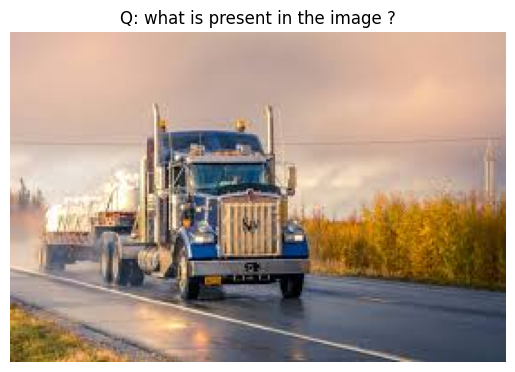

what is present in the image ? the cover of the book , the cover of the book , by jo h n m n ing ing
None


In [29]:
img   =  "/Users/saptarshimallikthakur/Pictures/New Folder With Items/truck.jpeg"
ques  = "what is present in the image ?"
print(generate_answer(vlm2, img, ques))